# Chapter 36 — Building Scalar Autograd From Scratch

## Learning goals

Chapter 35 manually propagated derivatives through a computational graph.

This chapter builds a small scalar automatic-differentiation engine that performs that bookkeeping for us.

By the end of this chapter, you should be able to:

1. Explain automatic differentiation and scalar autograd.
2. Build a `TrackedNumber` that stores data, a gradient, parents, an operation, and a backward rule.
3. Record a computation graph during ordinary arithmetic.
4. Implement local backward rules for addition, multiplication, power, subtraction, and division.
5. Build a deterministic topological ordering.
6. Run `.backward()` from a final scalar result.
7. Explain why reverse topological order is required.
8. Explain why gradient contributions accumulate within a backward pass.
9. Verify gradients by hand and with finite differences.
10. Draw a graph containing node data and gradients.
11. Use the engine in a tiny training loop.
12. Describe the engine's limitations relative to PyTorch.

## The goal

We want this program to work:

```python
first_number = TrackedNumber(2.0)
second_number = TrackedNumber(3.0)

result = first_number * second_number + second_number
result.backward()
```

The result should remember how it was created and compute:

```text
d result / d first_number
d result / d second_number
```

This is **reverse-mode automatic differentiation**, the mode used for neural-network training because one scalar loss depends on many parameters.

## Check the example by hand

Let `a = 2` and `b = 3`.

The expression is `result = a × b + b`, so its value is `9`.

Its derivatives are:

```text
d result / d a = b = 3
d result / d b = a + 1 = 3
```

The `+1` appears because `b` reaches the result through a second path.

In [1]:
first_data = 2.0
second_data = 3.0

product_data = first_data * second_data
result_data = product_data + second_data

expected_first_gradient = second_data
expected_second_gradient = first_data + 1.0

print("Product:", product_data)
print("Result:", result_data)
print("Expected first gradient:", expected_first_gradient)
print("Expected second gradient:", expected_second_gradient)

Product: 6.0
Result: 9.0
Expected first gradient: 3.0
Expected second gradient: 3.0


Our engine must reproduce the value and both derivatives without receiving a handwritten derivative for the complete expression.

## What each tracked scalar stores

Each `TrackedNumber` will store:

- `data`: its scalar numeric value.
- `gradient`: the derivative of the final output with respect to this value.
- `_previous_values`: the parent values used to create it.
- `_operation`: the operation that created it.
- `label`: an optional human-readable graph label.
- `_backward`: a local function that sends its gradient to its parents.

The parents are stored in a tuple so traversal and displayed output are deterministic.

## Local backward rules

If an output receives upstream gradient `g`, each operation sends these contributions to its inputs:

```text
z = x + y      → x receives g,          y receives g
z = x - y      → x receives g,          y receives -g
z = x × y      → x receives y × g,      y receives x × g
z = x ** p     → x receives p × x ** (p - 1) × g
z = x / y      → x receives g / y,      y receives -x × g / y²
```

The rules use `+=` because one value can receive contributions through several graph paths.

## Implement the complete scalar engine

The class below is defined once in its final form.

Arithmetic methods compute forward data, create an output node, and attach one local backward closure.

In [2]:
from collections.abc import Callable


class TrackedNumber:
    def __init__(
        self,
        data: float,
        previous_values: tuple["TrackedNumber", ...] = (),
        operation: str = "",
        label: str = "",
    ) -> None:
        self.data = float(data)
        self.gradient = 0.0
        self._previous_values = previous_values
        self._operation = operation
        self.label = label
        self._backward: Callable[[], None] = lambda: None

    def __repr__(self) -> str:
        return (
            f"TrackedNumber(data={self.data}, "
            f"gradient={self.gradient}, "
            f"label={self.label!r})"
        )

    @staticmethod
    def _ensure_tracked(value: object) -> "TrackedNumber":
        if isinstance(value, TrackedNumber):
            return value

        if isinstance(value, int | float):
            return TrackedNumber(float(value))

        raise TypeError(
            f"Expected a TrackedNumber, int, or float. Received {type(value).__name__}."
        )

    def __add__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data + other_value.data,
            previous_values=(self, other_value),
            operation="+",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient += output.gradient

        output._backward = _backward
        return output

    def __radd__(self, other: object) -> "TrackedNumber":
        return self + other

    def __sub__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data - other_value.data,
            previous_values=(self, other_value),
            operation="-",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient -= output.gradient

        output._backward = _backward
        return output

    def __rsub__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) - self

    def __mul__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        left_data = self.data
        right_data = other_value.data
        output = TrackedNumber(
            left_data * right_data,
            previous_values=(self, other_value),
            operation="*",
        )

        def _backward() -> None:
            self.gradient += right_data * output.gradient
            other_value.gradient += left_data * output.gradient

        output._backward = _backward
        return output

    def __rmul__(self, other: object) -> "TrackedNumber":
        return self * other

    def __truediv__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        numerator_data = self.data
        denominator_data = other_value.data

        if denominator_data == 0:
            raise ZeroDivisionError("Cannot divide by zero.")

        output = TrackedNumber(
            numerator_data / denominator_data,
            previous_values=(self, other_value),
            operation="/",
        )

        def _backward() -> None:
            self.gradient += output.gradient / denominator_data
            other_value.gradient -= (
                numerator_data * output.gradient / denominator_data**2
            )

        output._backward = _backward
        return output

    def __rtruediv__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) / self

    def __pow__(self, exponent: int | float) -> "TrackedNumber":
        if not isinstance(exponent, int | float):
            raise TypeError("Only int and float constant exponents are supported.")

        base_data = self.data
        output_data = base_data**exponent

        if isinstance(output_data, complex):
            raise ValueError("This engine supports real-valued powers only.")

        output = TrackedNumber(
            output_data,
            previous_values=(self,),
            operation=f"**{exponent}",
        )

        def _backward() -> None:
            self.gradient += exponent * base_data ** (exponent - 1) * output.gradient

        output._backward = _backward
        return output

    def __neg__(self) -> "TrackedNumber":
        return self * -1.0

    def _topological_order(self) -> list["TrackedNumber"]:
        ordered_values = []
        visited_values = set()

        def visit(current_value: "TrackedNumber") -> None:
            if current_value in visited_values:
                return

            visited_values.add(current_value)

            for previous_value in current_value._previous_values:
                visit(previous_value)

            ordered_values.append(current_value)

        visit(self)
        return ordered_values

    def zero_grad(self) -> None:
        for value in self._topological_order():
            value.gradient = 0.0

    def backward(self) -> None:
        ordered_values = self._topological_order()

        for value in ordered_values:
            value.gradient = 0.0

        self.gradient = 1.0

        for value in reversed(ordered_values):
            value._backward()

The backward closures capture operand data from the forward pass.

This preserves the derivatives for the graph's original computation even if someone later reassigns an external variable.

The engine intentionally resets all graph gradients at the start of `backward()`, unlike PyTorch's default leaf-gradient accumulation.

## Inspect one leaf value

A newly created leaf has data but no parents, operation, or computed gradient.

In [3]:
leaf = TrackedNumber(2.0, label="leaf")

print(leaf)
print("Parents:", leaf._previous_values)
print("Operation:", repr(leaf._operation))

TrackedNumber(data=2.0, gradient=0.0, label='leaf')
Parents: ()
Operation: ''


Its gradient begins at zero because no backward pass has selected a final output yet.

## Record a graph with ordinary arithmetic

Build the hand-checked expression and inspect its intermediate product.

In [4]:
first_number = TrackedNumber(2.0, label="first_number")
second_number = TrackedNumber(3.0, label="second_number")

product = first_number * second_number
product.label = "product"

result = product + second_number
result.label = "result"

print("Product:", product)
print("Product parents:", [value.label for value in product._previous_values])
print("Product operation:", product._operation)
print()
print("Result:", result)
print("Result parents:", [value.label for value in result._previous_values])
print("Result operation:", result._operation)

Product: TrackedNumber(data=6.0, gradient=0.0, label='product')
Product parents: ['first_number', 'second_number']
Product operation: *

Result: TrackedNumber(data=9.0, gradient=0.0, label='result')
Result parents: ['product', 'second_number']
Result operation: +


The graph was created during the forward arithmetic.

No derivatives have been propagated yet.

## Why backward order matters

The final addition must send a gradient into `product` before multiplication uses `product.gradient`.

A forward topological order puts every parent before the child that depends on it:

```text
first_number, second_number, product, result
```

The backward pass reverses that order so later computations are processed before earlier ones.

In [5]:
forward_order = result._topological_order()
backward_order = list(reversed(forward_order))

print("Forward topological order:")
print([value.label for value in forward_order])

print()
print("Backward processing order:")
print([value.label for value in backward_order])

Forward topological order:
['first_number', 'second_number', 'product', 'result']

Backward processing order:
['result', 'product', 'second_number', 'first_number']


The shared `second_number` appears once in the ordering even though it has two outgoing paths.

The visited set prevents duplicate node processing, while `+=` accumulates both gradient contributions.

## Run the first complete backward pass

Calling `result.backward()` seeds `result.gradient = 1` and invokes local rules in reverse topological order.

In [6]:
result.backward()

print("Result:", result)
print("Product:", product)
print("First number:", first_number)
print("Second number:", second_number)

assert result.data == 9.0
assert first_number.gradient == 3.0
assert second_number.gradient == 3.0

Result: TrackedNumber(data=9.0, gradient=1.0, label='result')
Product: TrackedNumber(data=6.0, gradient=1.0, label='product')
First number: TrackedNumber(data=2.0, gradient=3.0, label='first_number')
Second number: TrackedNumber(data=3.0, gradient=3.0, label='second_number')


The engine matches the hand calculation: both input gradients are `3`.

## See gradient accumulation through two paths

The second number receives `2` from the product path and `1` from the direct addition path.

Their sum is `3`.

In [7]:
product_path_contribution = first_number.data * result.gradient
direct_addition_contribution = result.gradient

print("Product-path contribution:", product_path_contribution)
print("Direct-addition contribution:", direct_addition_contribution)
print("Accumulated gradient:", second_number.gradient)

assert (
    second_number.gradient == product_path_contribution + direct_addition_contribution
)

Product-path contribution: 2.0
Direct-addition contribution: 1.0
Accumulated gradient: 3.0


Overwriting instead of accumulating would lose one of these valid paths.

## Repeated backward calls are deterministic here

This teaching engine clears every reachable gradient before each backward pass.

Calling backward twice therefore recomputes the same derivatives instead of mixing fresh and stale internal-node gradients.

In [8]:
result.backward()
first_gradient_after_repeat = first_number.gradient
second_gradient_after_repeat = second_number.gradient

result.backward()

print("First gradient:", first_number.gradient)
print("Second gradient:", second_number.gradient)

assert first_number.gradient == first_gradient_after_repeat == 3.0
assert second_number.gradient == second_gradient_after_repeat == 3.0

First gradient: 3.0
Second gradient: 3.0


PyTorch usually accumulates leaf gradients across backward calls until they are explicitly cleared.

We will learn that behavior later; this engine chooses automatic clearing to keep one backward pass self-contained.

## Test addition and reverse addition

Operations with ordinary Python numbers use an automatically created constant node.

In [9]:
addition_input = TrackedNumber(4.0, label="addition_input")
addition_result = 3.0 + addition_input
addition_result.label = "addition_result"
addition_result.backward()

print("Result data:", addition_result.data)
print("Input gradient:", addition_input.gradient)

assert addition_result.data == 7.0
assert addition_input.gradient == 1.0

Result data: 7.0
Input gradient: 1.0


The derivative of `3 + x` with respect to `x` is `1`.

## Test multiplication

For `z = x × y`, each input receives the other input's forward data times the upstream gradient.

In [10]:
left = TrackedNumber(4.0, label="left")
right = TrackedNumber(-2.0, label="right")
multiplication_result = left * right
multiplication_result.backward()

print("Result data:", multiplication_result.data)
print("Left gradient:", left.gradient)
print("Right gradient:", right.gradient)

assert multiplication_result.data == -8.0
assert left.gradient == -2.0
assert right.gradient == 4.0

Result data: -8.0
Left gradient: -2.0
Right gradient: 4.0


The multiplication rule used the values saved by the forward operation.

## Test power

The exponent is a fixed Python constant rather than another tracked input.

In [11]:
power_input = TrackedNumber(3.0, label="power_input")
power_result = power_input**2
power_result.backward()

print("Result data:", power_result.data)
print("Input gradient:", power_input.gradient)

assert power_result.data == 9.0
assert power_input.gradient == 6.0

Result data: 9.0
Input gradient: 6.0


The derivative of `x²` at `x = 3` is `2x = 6`.

## Test subtraction

The right input receives the negative upstream gradient.

In [12]:
minuend = TrackedNumber(10.0, label="minuend")
subtrahend = TrackedNumber(4.0, label="subtrahend")
subtraction_result = minuend - subtrahend
subtraction_result.backward()

print("Result data:", subtraction_result.data)
print("Minuend gradient:", minuend.gradient)
print("Subtrahend gradient:", subtrahend.gradient)

assert subtraction_result.data == 6.0
assert minuend.gradient == 1.0
assert subtrahend.gradient == -1.0

Result data: 6.0
Minuend gradient: 1.0
Subtrahend gradient: -1.0


Direct subtraction keeps the graph operation and its local derivative easy to inspect.

## Test division

Division has different local derivatives for numerator and denominator.

In [13]:
numerator = TrackedNumber(6.0, label="numerator")
denominator = TrackedNumber(3.0, label="denominator")
division_result = numerator / denominator
division_result.backward()

print("Result data:", division_result.data)
print("Numerator gradient:", numerator.gradient)
print("Denominator gradient:", denominator.gradient)

assert division_result.data == 2.0
assert abs(numerator.gradient - 1.0 / 3.0) < 1e-12
assert abs(denominator.gradient + 2.0 / 3.0) < 1e-12

Result data: 2.0
Numerator gradient: 0.3333333333333333
Denominator gradient: -0.6666666666666666


The denominator gradient is negative because increasing the denominator lowers a positive quotient.

## Test a composite expression with finite differences

Use all core operations in `f(x, y) = (x - y)² / (x + 2y)`.

Central differences provide an independent numerical check.

In [14]:
composite_x = TrackedNumber(4.0, label="composite_x")
composite_y = TrackedNumber(1.0, label="composite_y")
composite_result = (composite_x - composite_y) ** 2 / (composite_x + 2.0 * composite_y)
composite_result.backward()


def plain_composite(x_value: float, y_value: float) -> float:
    return (x_value - y_value) ** 2 / (x_value + 2.0 * y_value)


small_change = 0.0001
numerical_x_gradient = (
    plain_composite(4.0 + small_change, 1.0) - plain_composite(4.0 - small_change, 1.0)
) / (2 * small_change)
numerical_y_gradient = (
    plain_composite(4.0, 1.0 + small_change) - plain_composite(4.0, 1.0 - small_change)
) / (2 * small_change)

print("Result data:", composite_result.data)
print("Autograd x gradient:", composite_x.gradient)
print("Numerical x gradient:", numerical_x_gradient)
print("Autograd y gradient:", composite_y.gradient)
print("Numerical y gradient:", numerical_y_gradient)

assert abs(composite_x.gradient - numerical_x_gradient) < 1e-8
assert abs(composite_y.gradient - numerical_y_gradient) < 1e-8

Result data: 1.5
Autograd x gradient: 0.75
Numerical x gradient: 0.7499999999316387
Autograd y gradient: -1.5
Numerical y gradient: -1.5000000022191706


The engine combines many local rules without a handwritten derivative for the complete expression.

## Compute squared error gradients automatically

Rebuild the line-model computation from Chapter 35 using tracked scalars.

In [15]:
tracked_input = TrackedNumber(5.0, label="input")
tracked_target = TrackedNumber(10.0, label="target")
tracked_weight = TrackedNumber(1.0, label="weight")
tracked_bias = TrackedNumber(0.0, label="bias")

tracked_first_value = tracked_input * tracked_weight
tracked_first_value.label = "first_value"

tracked_prediction = tracked_first_value + tracked_bias
tracked_prediction.label = "prediction"

tracked_error = tracked_prediction - tracked_target
tracked_error.label = "error"

tracked_loss = tracked_error**2
tracked_loss.label = "loss"

tracked_loss.backward()

print("Loss:", tracked_loss)
print("Weight:", tracked_weight)
print("Bias:", tracked_bias)
print("Input:", tracked_input)
print("Target:", tracked_target)

assert tracked_loss.data == 25.0
assert tracked_weight.gradient == -50.0
assert tracked_bias.gradient == -10.0
assert tracked_input.gradient == -10.0
assert tracked_target.gradient == 10.0

Loss: TrackedNumber(data=25.0, gradient=1.0, label='loss')
Weight: TrackedNumber(data=1.0, gradient=-50.0, label='weight')
Bias: TrackedNumber(data=0.0, gradient=-10.0, label='bias')
Input: TrackedNumber(data=5.0, gradient=-10.0, label='input')
Target: TrackedNumber(data=10.0, gradient=10.0, label='target')


The engine reproduces the complete manual backward pass from Chapter 35.

Weight and bias are the trainable parameters, while input and target derivatives are computed but not used for updates.

## Draw node data and gradients

Walk backward from the final loss and use fixed positions for this small graph.

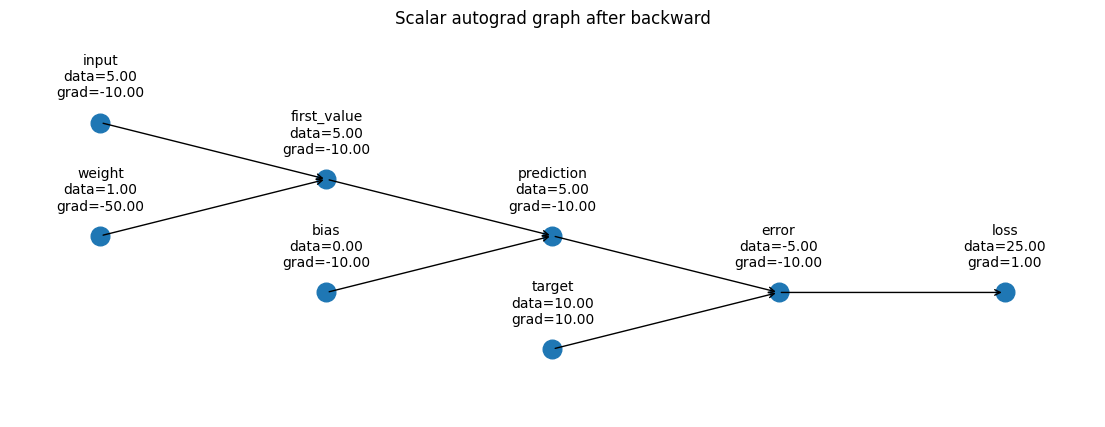

In [16]:
import matplotlib.pyplot as plt


def collect_graph(
    final_value: TrackedNumber,
) -> tuple[list[TrackedNumber], list[tuple[TrackedNumber, TrackedNumber]]]:
    nodes = []
    edges = []
    visited_values = set()

    def visit(current_value: TrackedNumber) -> None:
        if current_value in visited_values:
            return

        visited_values.add(current_value)
        nodes.append(current_value)

        for previous_value in current_value._previous_values:
            edges.append((previous_value, current_value))
            visit(previous_value)

    visit(final_value)
    return nodes, edges


graph_nodes, graph_edges = collect_graph(tracked_loss)
node_positions = {
    "input": (0.0, 2.2),
    "weight": (0.0, 1.2),
    "first_value": (2.5, 1.7),
    "bias": (2.5, 0.7),
    "prediction": (5.0, 1.2),
    "target": (5.0, 0.2),
    "error": (7.5, 0.7),
    "loss": (10.0, 0.7),
}

plt.figure(figsize=(14, 5))

for start_node, end_node in graph_edges:
    if start_node.label in node_positions and end_node.label in node_positions:
        start_x, start_y = node_positions[start_node.label]
        end_x, end_y = node_positions[end_node.label]
        plt.annotate(
            "",
            xy=(end_x, end_y),
            xytext=(start_x, start_y),
            arrowprops={"arrowstyle": "->", "color": "black"},
        )

for node in graph_nodes:
    if node.label in node_positions:
        x_position, y_position = node_positions[node.label]
        node_text = f"{node.label}\ndata={node.data:.2f}\ngrad={node.gradient:.2f}"
        plt.scatter([x_position], [y_position], s=180, color="tab:blue")
        plt.text(
            x_position,
            y_position + 0.2,
            node_text,
            ha="center",
            va="bottom",
        )

plt.xlim(-1, 11)
plt.ylim(-0.4, 3)
plt.axis("off")
plt.title("Scalar autograd graph after backward")
plt.show()

Every node displays its forward data and the final loss derivative assigned during backward.

## Train with the scalar engine

Create a fresh graph on every step, run backward, and update ordinary parameter data.

Fresh graphs avoid stale computed nodes and mirror the usual define-by-run training pattern.

In [17]:
input_data = 5.0
target_data = 10.0
weight_data = 1.0
bias_data = 0.0
learning_rate = 0.01
number_of_steps = 12

print("step | weight | bias | prediction | loss | weight gradient | bias gradient")
print("-" * 90)

for step in range(number_of_steps):
    step_input = TrackedNumber(input_data, label="input")
    step_target = TrackedNumber(target_data, label="target")
    step_weight = TrackedNumber(weight_data, label="weight")
    step_bias = TrackedNumber(bias_data, label="bias")

    step_prediction = step_input * step_weight + step_bias
    step_loss = (step_prediction - step_target) ** 2
    step_loss.backward()

    print(
        f"{step:>4} | "
        f"{step_weight.data:>8.5f} | "
        f"{step_bias.data:>8.5f} | "
        f"{step_prediction.data:>10.5f} | "
        f"{step_loss.data:>9.5f} | "
        f"{step_weight.gradient:>15.5f} | "
        f"{step_bias.gradient:>13.5f}"
    )

    weight_data -= learning_rate * step_weight.gradient
    bias_data -= learning_rate * step_bias.gradient

print()
print("Final parameter data:", (weight_data, bias_data))

step | weight | bias | prediction | loss | weight gradient | bias gradient
------------------------------------------------------------------------------------------
   0 |  1.00000 |  0.00000 |    5.00000 |  25.00000 |       -50.00000 |     -10.00000
   1 |  1.50000 |  0.10000 |    7.60000 |   5.76000 |       -24.00000 |      -4.80000
   2 |  1.74000 |  0.14800 |    8.84800 |   1.32710 |       -11.52000 |      -2.30400
   3 |  1.85520 |  0.17104 |    9.44704 |   0.30576 |        -5.52960 |      -1.10592
   4 |  1.91050 |  0.18210 |    9.73458 |   0.07045 |        -2.65421 |      -0.53084
   5 |  1.93704 |  0.18741 |    9.87260 |   0.01623 |        -1.27402 |      -0.25480
   6 |  1.94978 |  0.18996 |    9.93885 |   0.00374 |        -0.61153 |      -0.12231
   7 |  1.95589 |  0.19118 |    9.97065 |   0.00086 |        -0.29353 |      -0.05871
   8 |  1.95883 |  0.19177 |    9.98591 |   0.00020 |        -0.14090 |      -0.02818
   9 |  1.96024 |  0.19205 |    9.99324 |   0.00005 |       

The update remains manual, but every derivative is produced by the recorded graph and local backward rules.

## Compare autograd with the manual formulas

Check one step against the derivatives from Chapter 35.

In [18]:
check_input = TrackedNumber(5.0)
check_target = TrackedNumber(10.0)
check_weight = TrackedNumber(1.0)
check_bias = TrackedNumber(0.0)

check_prediction = check_input * check_weight + check_bias
check_loss = (check_prediction - check_target) ** 2
check_loss.backward()

manual_weight_gradient = (
    2 * (check_prediction.data - check_target.data) * check_input.data
)
manual_bias_gradient = 2 * (check_prediction.data - check_target.data)

print("Autograd weight gradient:", check_weight.gradient)
print("Manual weight gradient:", manual_weight_gradient)
print("Autograd bias gradient:", check_bias.gradient)
print("Manual bias gradient:", manual_bias_gradient)

assert check_weight.gradient == manual_weight_gradient
assert check_bias.gradient == manual_bias_gradient

Autograd weight gradient: -50.0
Manual weight gradient: -50.0
Autograd bias gradient: -10.0
Manual bias gradient: -10.0


Autograd changes the bookkeeping, not the mathematics.

## Engine limitations

This engine is intentionally small.

It does not provide:

- Vector, matrix, or tensor operations.
- GPU execution or optimized numerical kernels.
- Broadcasting.
- A large library of differentiable functions.
- Memory-saving graph controls.
- Higher-order derivatives.
- Production-grade mutation and numerical-domain checks.

It also tracks constants by default and supports only constant real exponents.

Those limits keep the mechanism visible.

## A clean scalar-autograd pipeline

This final cell verifies values, graph order, shared-node accumulation, and squared-error gradients.

In [19]:
pipeline_a = TrackedNumber(2.0, label="a")
pipeline_b = TrackedNumber(3.0, label="b")
pipeline_result = pipeline_a * pipeline_b + pipeline_b
pipeline_result.label = "result"
pipeline_result.backward()

pipeline_input = TrackedNumber(5.0, label="input")
pipeline_target = TrackedNumber(10.0, label="target")
pipeline_weight = TrackedNumber(1.0, label="weight")
pipeline_bias = TrackedNumber(0.0, label="bias")
pipeline_prediction = pipeline_input * pipeline_weight + pipeline_bias
pipeline_loss = (pipeline_prediction - pipeline_target) ** 2
pipeline_loss.backward()

assert pipeline_result.data == 9.0
assert pipeline_a.gradient == 3.0
assert pipeline_b.gradient == 3.0
assert pipeline_loss.data == 25.0
assert pipeline_weight.gradient == -50.0
assert pipeline_bias.gradient == -10.0

print("Shared-node result:", pipeline_result.data)
print("d result / d a:", pipeline_a.gradient)
print("d result / d b:", pipeline_b.gradient)
print("Squared error loss:", pipeline_loss.data)
print("d loss / d weight:", pipeline_weight.gradient)
print("d loss / d bias:", pipeline_bias.gradient)
print("All scalar-autograd checks passed.")

Shared-node result: 9.0
d result / d a: 3.0
d result / d b: 3.0
Squared error loss: 25.0
d loss / d weight: -50.0
d loss / d bias: -10.0
All scalar-autograd checks passed.


## What not to do

- Do not process parent backward rules before their downstream gradients arrive.
- Do not overwrite a gradient contribution when a node has several paths to the result.
- Do not confuse graph-gradient clearing between passes with accumulation inside one pass.
- Do not mutate values and expect already computed child data to update automatically.
- Do not assume every mathematical domain is supported by this tiny real-scalar engine.
- Do not mistake this teaching implementation for an efficient tensor library.

## Gotchas

- The forward pass records parents and backward closures.
- Backward starts by setting the final scalar's gradient to `1`.
- Reverse topological order ensures every downstream contribution arrives before a node propagates.
- Shared nodes appear once in the ordering but can receive many accumulated contributions.
- Captured forward data is needed by multiplication, division, and power backward rules.
- This engine clears reachable gradients at the start of every backward call.
- A new forward computation creates a new graph.

## Takeaways

Each `TrackedNumber` stores scalar data, a gradient, parents, an operation, and a local backward rule.

Arithmetic builds a graph during the forward computation.

`.backward()` builds a topological order, reverses it, and applies the chain rule from the final result to earlier values.

For `result = a × b + b` at `a = 2` and `b = 3`, the engine computes:

```text
result = 9
d result / d a = 3
d result / d b = 3
```

The shared `b` gradient is the sum of contributions from two paths.

Automatic differentiation automates derivative bookkeeping without changing the underlying calculus.

## What comes next

The next chapter introduces PyTorch tensors and autograd.

PyTorch applies the same ideas to efficient tensor operations and production-scale computation graphs.